<a href="https://colab.research.google.com/github/josimardtm/ASP1/blob/main/ASP1_Ejemplo_M%C3%A1quinaS%C3%ADncrona_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas

def fasor(mag,angle):
# Función para definir un fasor con magnitud y ángulo
# mag: magnitud en valores p.u.
# angle: ángulo en grados
  angle = np.deg2rad(angle)
  f = mag*(np.cos(angle) + 1j*np.sin(angle));
  return f;

Sb=1250e3 # kVA
Vb=4160 # V
Ra=0.126 # Ohm
Xa=3 # Ohm

Zpu=(Ra+1j*Xa)/(Vb**2/Sb)
Va=fasor(1,0)
Sa=fasor(1,36.87)
Ia=np.conjugate(Sa/Va)

Ei=Va+Ia*Zpu
Si=Ei*np.conjugate(Ia)

print('Sa=',np.abs(Sa),'|',np.angle(Sa)*180/np.pi)
print('Ia=',np.abs(Ia),'|',np.angle(Ia)*180/np.pi)
print('Ei=',np.abs(Ei),'|',np.angle(Ei)*180/np.pi)
print('Si=',np.abs(Si),'|',np.angle(Si)*180/np.pi)


Sa= 1.0 | 36.87
Ia= 1.0 | -36.87
Ei= 1.1496227301917568 | 8.397632909801889
Si= 1.149622730191757 | 45.26763290980188


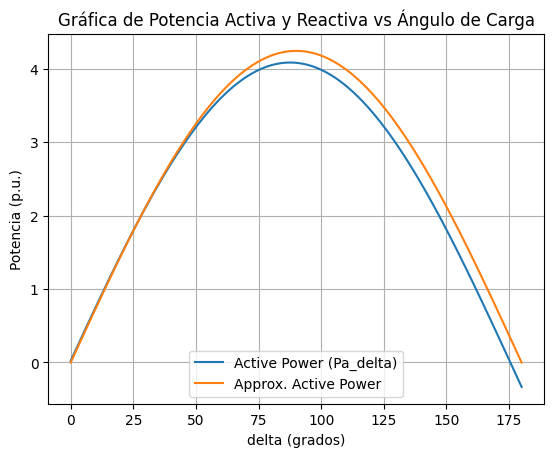

Límite de estabilidad en estado estable= 4.085657013826491 p.u


In [11]:
delta=np.linspace(0,180,100)

Ei=fasor(np.abs(Ei),delta) # conjunto de valores para distintos ángulos
Sa_delta=0.8*np.conjugate((Ei-Va)/Zpu)
Pa_delta=np.real(Sa_delta)
#Qa_delta=np.imag(Sa_delta)
Pa_delta_aprox=(0.8*np.abs(Ei)/np.imag(Zpu))*np.sin(np.deg2rad(delta))

# Gráfica de Pa_delta vs delta
plt.figure()
#plt.plot(delta, Pa_delta, label='Active Power (Pa_delta)')
plt.plot(delta, Pa_delta, label='Active Power (Pa_delta)')
plt.plot(delta, Pa_delta_aprox, label='Approx. Active Power')
plt.xlabel('delta (grados)')
plt.ylabel('Potencia (p.u.)')
plt.title('Gráfica de Potencia Activa y Reactiva vs Ángulo de Carga')
plt.grid(True)
plt.legend()
plt.show()

limite=max(Pa_delta)
print('Límite de estabilidad en estado estable=',limite,'p.u')

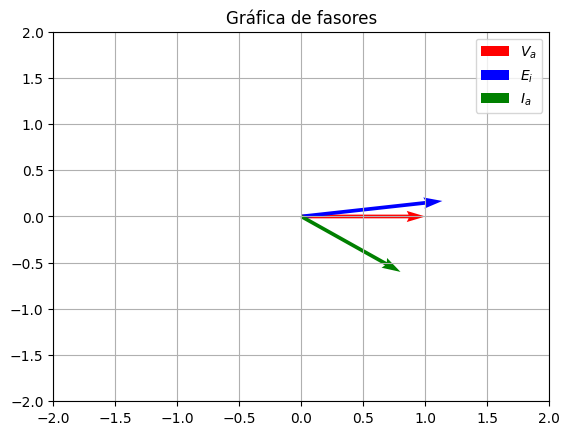

In [ ]:
# Diagrama fasorial

def vector(fasor):
  x=np.real(fasor)
  y=np.imag(fasor)
  return np.array([x,y])

vectorV1 = vector(fasor=Va)
vectorV2 = vector(fasor=Ei)
vectorI = vector(fasor=Ia)

# Crear la figura
plt.figure()

# Graficar vectores
plt.quiver(0, 0, vectorV1[0], vectorV1[1], angles='xy', scale_units='xy', scale=1, color='r', label='$V_a$')
plt.quiver(0, 0, vectorV2[0], vectorV2[1], angles='xy', scale_units='xy', scale=1, color='b', label='$E_i$')
plt.quiver(0, 0, vectorI[0], vectorI[1], angles='xy', scale_units='xy', scale=1, color='g', label='$I_a$')

# Ajustar los ejes
plt.xlim(-2, 2)
plt.ylim(-2, 2)

# Etiquetas y leyenda
#plt.xlabel('Eje X')
#plt.ylabel('Eje Y')
plt.title('Gráfica de fasores')
plt.legend()

# Mostrar la gráfica
plt.grid(True)
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas

def fasor(mag,angle):
# Función para definir un fasor con magnitud y ángulo
# mag: magnitud en valores p.u.
# angle: ángulo en grados
  angle = np.deg2rad(angle)
  f = mag*(np.cos(angle) + 1j*np.sin(angle));
  return f;


V1=fasor(1,0)
I=fasor(0.8,-25.84)
Xs=1.7241

Ei=V1+1j*Xs*I
Si=Ei*np.conjugate(I)
S1=V1*np.conjugate(I)

print('Ei=',np.abs(Ei),np.angle(Ei)*180/np.pi)
print('Si=',Si)
print('S1=',S1)

# Caso a




Ei= 2.026020235691215 37.78604974686344
Si= (0.7200117627176118+1.4521116274665875j)
S1= (0.7200117627176118+0.3486876274665873j)


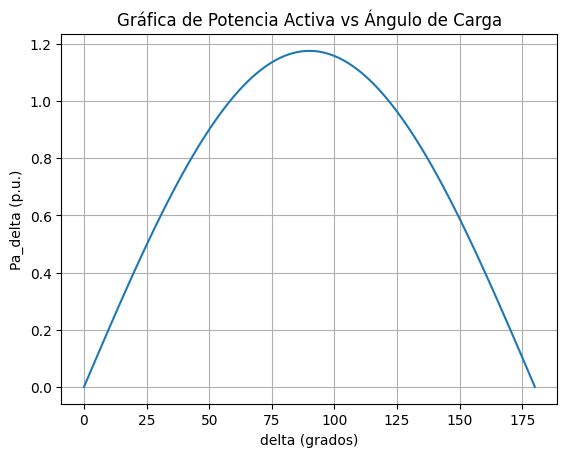

Límite de estabilidad en estado estable= 1.1749696745034348 p.u


In [ ]:
# Gráfica de potencia dejando las tensiones fijas
delta=np.linspace(0,180,100)

Ei=fasor(np.abs(Ei),delta)
Zpu=1J*Xs
Sa_delta=V1*(Ei-V1)/Zpu
Pa_delta=np.real(Sa_delta)

# Gráfica de Pa_delta vs delta
plt.figure()
plt.plot(delta, Pa_delta)
plt.xlabel('delta (grados)')
plt.ylabel('Pa_delta (p.u.)')
plt.title('Gráfica de Potencia Activa vs Ángulo de Carga')
plt.grid(True)
plt.show()

limite=max(Pa_delta)
print('Límite de estabilidad en estado estable=',limite,'p.u')

In [ ]:
import numpy as np

Zpu=(0.126+1j*3)/(4160**2/1250e3)
print(Zpu)
Ei=1+Zpu*(1*(np.cos(np.deg2rad(-36.87)) + 1j*np.sin(np.deg2rad(-36.87))))
print(abs(Ei),'|',np.angle(Ei)*180/np.pi)

(0.00910110022189349+0.2166928624260355j)
1.1496227301917568 | 8.397632909801889


In [23]:


Ei=1+0.8*(np.cos(np.deg2rad(-25.84)) + 1j*np.sin(np.deg2rad(-25.84)))*1j*(1.7421)

Sa=1*0.8*(np.cos(np.deg2rad(25.84)) + 1j*np.sin(np.deg2rad(25.84)))

Ei_nuevo=0.8*Ei

delta_nuevo=np.arcsin(0.72*1.7421/np.abs(Ei_nuevo))

Qa=(np.abs(Ei_nuevo)*np.cos(delta_nuevo)-1)/1.7421

print(abs(Ei),'|',np.angle(Ei)*180/np.pi)
print(Sa)
print('E_i_nuevo=',abs(Ei_nuevo),'|',np.angle(Ei_nuevo)*180/np.pi)
print(delta_nuevo*180/np.pi)
print(Qa)

2.03893142945492 | 37.965808084140605
(0.7200117627176118+0.3486876274665873j)
E_i_nuevo= 1.6311451435639361 | 37.965808084140605
50.26205262834271
0.024541640052302534
